# Sign Language Translator using Transfer Learning

## 1. Imports and Configuration

In [1]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data' / 'asl_alphabet_train' / 'asl_alphabet_train'
MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)

# Safer laptop-friendly settings. Increase to (224, 224) and 32 only if you have enough RAM/GPU memory.
IMG_SIZE = (160, 160)
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2

print('TensorFlow:', tf.__version__)
print('Dataset path:', DATA_DIR)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.16.1
Dataset path: C:\Users\patid\OneDrive\Documents\Playground\asl-sign-language-translator\data\asl_alphabet_train\asl_alphabet_train
GPU devices: []


## 2. Check Dataset

After downloading and extracting the Kaggle dataset, the training folders should look like `data/asl_alphabet_train/asl_alphabet_train/A`, `B`, `C`, etc.

Classes (29): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


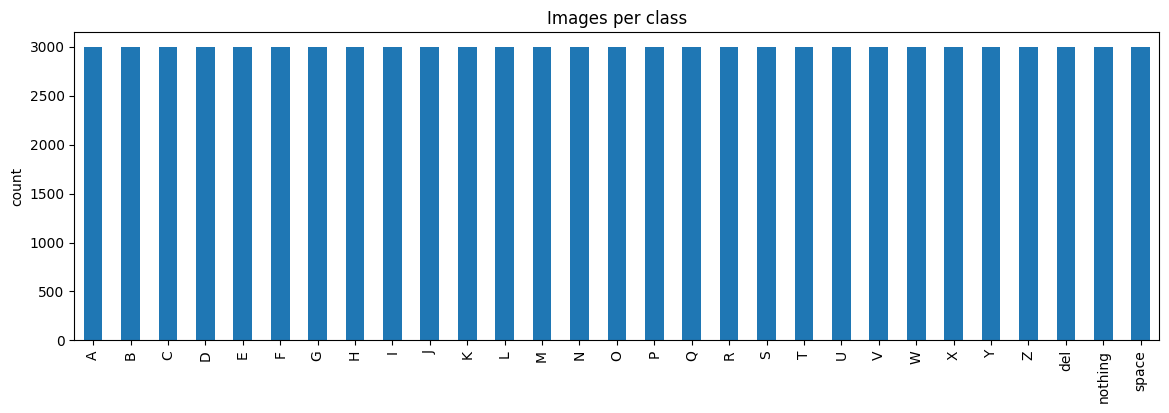

In [2]:
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f'Dataset not found at {DATA_DIR}. Run: python src/download_dataset.py --output data'
    )

class_names = sorted([path.name for path in DATA_DIR.iterdir() if path.is_dir()])
print(f'Classes ({len(class_names)}):', class_names)

counts = {name: len(list((DATA_DIR / name).glob('*.jpg'))) for name in class_names}
pd.Series(counts).sort_index().plot(kind='bar', figsize=(14, 4), title='Images per class')
plt.ylabel('count')
plt.show()

## 3. Build Train and Validation Datasets

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(num_classes, class_names)

AUTOTUNE = tf.data.AUTOTUNE
# Do not call .cache() here. The ASL dataset is large and can exhaust RAM/GPU memory.
train_ds = train_ds.shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Found 87000 files belonging to 29 classes.
Using 69600 files for training.
Found 87000 files belonging to 29 classes.
Using 17400 files for validation.
29 ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## 4. Visualize Samples

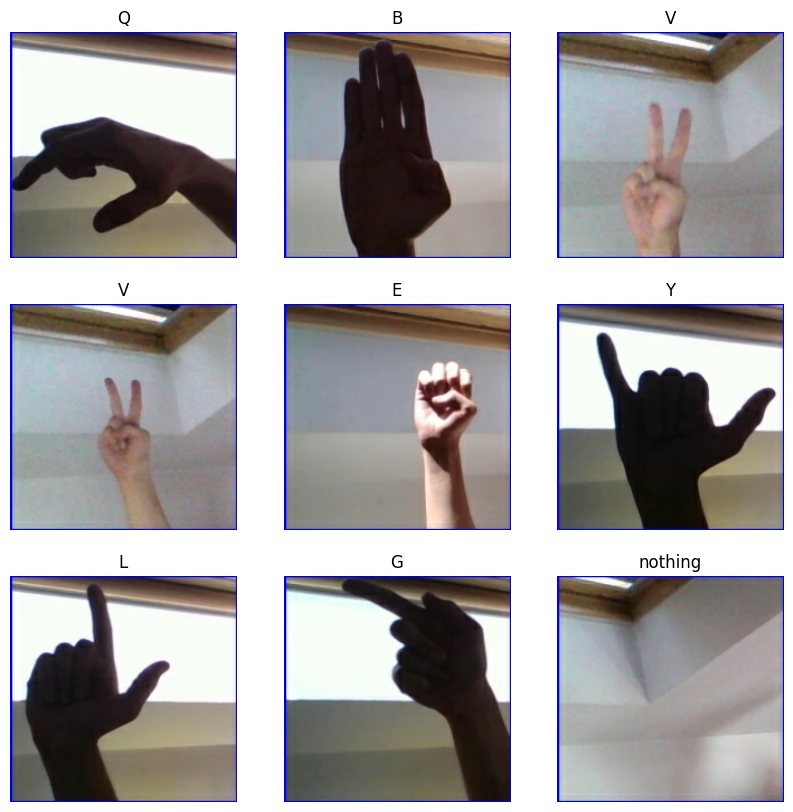

In [4]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[int(np.argmax(labels[i]))])
        plt.axis('off')
plt.show()

## 5. Build Transfer Learning Model

MobileNetV2 gives strong accuracy with a small enough model for interactive inference.

In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.12),
    tf.keras.layers.RandomContrast(0.15),
], name='augmentation')

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet',
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='asl_mobilenetv2')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "asl_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)   │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ augmentation (Sequential)     │ (None, 224, 224, 3)   │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ true_divide (TrueDivide)      │ (None, 224, 224, 3)   │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ subtract (Subtract)           │ (None, 224, 224, 3)   │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ mobilenetv2_1.00_224          │ (None, 7, 7, 1280)    │    2,257,984 │
│ (Functional)                  │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ global_average_pooling2d      │ (None, 1280)          │            0 │
│ (GlobalAveragePooling2D)      │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout (Dropout)             │ (None, 1280)          │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 29)            │       37,149 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 2,295,133 (8.76 MB)

 Trainable params: 37,149 (145.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Train Classification Head

In [7]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_DIR / 'asl_mobilenetv2.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks,
)

Epoch 1/8


ResourceExhaustedError: Graph execution error:

Detected at node asl_mobilenetv2_1/mobilenetv2_1.00_224_1/block_1_pad_1/Pad defined at (most recent call last):
  File "C:\Users\patid\AppData\Local\Programs\Python\Python311\Lib\runpy.py", line 198, in _run_module_as_main

  File "C:\Users\patid\AppData\Local\Programs\Python\Python311\Lib\runpy.py", line 88, in _run_code

  File "C:\Users\patid\OneDrive\Documents\Playground\asl-sign-language-translator\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "C:\Users\patid\OneDrive\Documents\Playground\asl-sign-language-translator\.venv\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance

  File "C:\Users\patid\OneDrive\Documents\Playground\asl-sign-language-translator\.venv\Lib\site-packages\ipykernel\kernelapp.py", line 807, in start

  File "C:\Users\patid\OneDrive\Documents\Playground\asl-sign-language-translator\.venv\Lib\site-packages\tornado\platform\asyncio.py", line 211, in star

## 7. Fine Tune Top Layers

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-35]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=callbacks,
)

## 8. Evaluate

In [ ]:
best_model = tf.keras.models.load_model(MODEL_DIR / 'asl_mobilenetv2.keras')
val_loss, val_accuracy = best_model.evaluate(val_ds)
print(f'Validation accuracy: {val_accuracy:.4f}')

y_true = []
y_pred = []
for images, labels in val_ds:
    probabilities = best_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(probabilities, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

## 9. Save Labels for the Streamlit App

In [ ]:
with (MODEL_DIR / 'labels.json').open('w', encoding='utf-8') as handle:
    json.dump(class_names, handle, indent=2)

print('Saved model:', MODEL_DIR / 'asl_mobilenetv2.keras')
print('Saved labels:', MODEL_DIR / 'labels.json')

## 10. Quick OpenCV Inference Test

Use a single image from the validation folders to confirm the exported model works with the same OpenCV preprocessing used by the app.

In [ ]:
import cv2

sample_path = next(DATA_DIR.glob('*/*.jpg'))
frame = cv2.imread(str(sample_path))
rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
resized = cv2.resize(rgb, IMG_SIZE, interpolation=cv2.INTER_AREA)
batch = np.expand_dims(resized.astype(np.float32), axis=0)

probabilities = best_model.predict(batch, verbose=0)[0]
prediction = class_names[int(np.argmax(probabilities))]

plt.imshow(rgb)
plt.title(f'Predicted: {prediction} ({probabilities.max():.2%})')
plt.axis('off')
plt.show()